# RNN model for Sentiment Analysis
## Samll Dataset 
https://data.world/datafiniti/consumer-reviews-of-amazon-products

## Methods
- display_confusion_matrix
- save_complete_model
- preprocess_data
- create_rnn_model
- train_and_evaluate
- plot_training_history

In [27]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, BatchNormalization, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from keras.optimizers import *
import time
import os
import datetime
import json
import warnings
warnings.filterwarnings('ignore')

base_path = "/home/subha/aiwork/project"


def display_confusion_matrix(confusion_matrix, 
                             rnn_type,
                           labels=['Negative', 'Positive'],
                           title='Confusion Matrix',
                           figsize=(10, 8),
                           normalize=False,
                           cmap='Blues',
                           save_path=None
                           ):
    """
    Display a confusion matrix with annotations and metrics
    
    Args:
        confusion_matrix: 2x2 numpy array containing confusion matrix values labels: List of labels for classes
        (default: ['Negative', 'Positive'])
        title: Title for the plot (default: 'Confusion Matrix') figsize: Tuple for figure size (default: (10, 8))
        normalize: Whether to normalize values to percentages (default: False) cmap: Color map for the heatmap (default: 'Blues')
        save_path: Path to save the figure (default: None)
        
    Returns:
        matplotlib figure object
    """
    # Create figure and axes
    fig, ax = plt.subplots(figsize=figsize,dpi=300)
    
    # Normalize matrix if requested
    if normalize:
        confusion_matrix = (confusion_matrix.astype('float') / 
                          confusion_matrix.sum(axis=1)[:, np.newaxis])
        fmt = '.2%'
    else:
        fmt = 'd'
    
    # Create heatmap
    sns.heatmap(confusion_matrix, 
                annot=True,            # Show numbers in cells
                fmt=fmt,               # Number format
                cmap=cmap,             # Color scheme
                square=True,           # Square cells
                xticklabels=labels,    # X-axis labels
                yticklabels=labels,    # Y-axis labels
                ax=ax)                 # Axis to plot on
    
    # Calculate metrics
    tn, fp, fn, tp = confusion_matrix.ravel()
    total = tn + fp + fn + tp
    
    # Calculate key metrics
    accuracy = (tp + tn) / total
    precision = tp / (tp + fp) if (tp + fp) != 0 else 0
    recall = tp / (tp + fn) if (tp + fn) != 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0
    
    # Add metrics text
    metrics_text = (
        f'Accuracy: {accuracy:.3f}\n'
        f'Precision: {precision:.3f}\n'
        f'Recall: {recall:.3f}\n'
        f'F1 Score: {f1:.3f}'
    )
    
    # Add metrics box
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    ax.text(1.5, 0.5, metrics_text,
            transform=ax.transAxes,
            bbox=props,
            fontsize=10,
            verticalalignment='center')
    
    # Customize plot
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    plt.title(title +'-'+ rnn_type)
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()

    #plt.show()
    
    # # Save figure if path provided
    # if save_path:
    #     plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig

def save_complete_model(model, model_type, custom_name=None):
    """
    Save the complete model including architecture, weights, and optimizer state
    
    Args:
        model: Keras model instance
        model_type (str): Type of the model
        custom_name (str, optional): Custom name for the model
        
    Returns:
        str: Path to the saved model
    """
    try:
        epoch_time = str(int(time.time()))
        model_name = f"{custom_name}_{epoch_time}.keras"
        save_path = os.path.join(base_path, "complete_models",custom_name)
        model_path = os.path.join(save_path,model_name)
        
        # Save the complete model
        model.save(model_path)
        
        # Save additional metadata
        metadata = {
            "model_type": model_type,
            "save_date": datetime.datetime.now().isoformat(),
            "keras_version": tf.keras.__version__,
            "model_name": model_name
        }
        
        metadata_path = os.path.join(save_path, f"metadata_{epoch_time}.json")
        with open(metadata_path, 'w') as f:
            json.dump(metadata, f, indent=4)
            
        print(f"Model successfully saved to: {save_path}")
        return save_path
        
    except Exception as e:
        print(f"Error saving complete model: {str(e)}")
        raise

def preprocess_data(texts, labels, tokenizer=None, max_words=5000, max_len=100):
    """
    Preprocess text data for RNN input
    """
    # Tokenize texts
    if tokenizer is None:
        tokenizer = Tokenizer(num_words=max_words)
        tokenizer.fit_on_texts(texts)
    
    # Convert texts to sequences
    sequences = tokenizer.texts_to_sequences(texts)
    
    # Pad sequences
    padded_sequences = pad_sequences(sequences, maxlen=max_len)
    
    return padded_sequences, tokenizer


def create_rnn_model(rnn_type, max_words=5000, max_len=100, embedding_dim=100):
    """
    Create RNN model based on specified type
    """
    print("=======================================================================================")
    print("I am in create_rnn_model")
    print("=======================================================================================")

    model = Sequential(name=rnn_type)
    model.add(Embedding(max_words, embedding_dim))
    
    # adding a LSTM layer 
    if rnn_type == 'simple':
        model.add(SimpleRNN(32, activation='relu'))
    elif rnn_type == 'lstm':## Add with attention
        model.add(LSTM(32, return_sequences=False))
    elif rnn_type == 'bilstm':
        # Add Bidirectional LSTM with attention
        model.add(Bidirectional(LSTM(32, return_sequences=False)))
        # Attention mechanism
        model.add(Attention())
    else :
        model.add(GRU(32))
    BatchNormalization()
    model.add(Dropout(0.2))
    
    #adding a dense layer with activation function of relu
    model.add(Dense(16, activation='relu'))
    BatchNormalization()
    model.add(Dropout(0.6))
    
    # adding the final output activation with activation function of softmax
    model.add(Dense(1, activation='sigmoid'))

    optimizer = Adam(learning_rate=0.001)
    
    model.compile(optimizer=optimizer,
                 loss='binary_crossentropy',
                 metrics=['accuracy'])
    #model.summary()
    
    return model

def train_and_evaluate(model, X_train, y_train, X_val, y_val, X_test, y_test, rnn_type, epochs=15):
    """
    Train model and evaluate performance
    """

    print("=======================================================================================")
    print("I am in train_and_evaluate")
    print("=======================================================================================")
    # Early stopping to prevent overfitting
    early_stopping = EarlyStopping(monitor='val_loss', 
                                 patience=3,
                                 restore_best_weights=True)
    
    # Variable rate
    lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1, min_lr=1e-5)
    
    # Train model

    history = model.fit(X_train, 
                        y_train,
                        #batch_size=32,
                        epochs=epochs,
                        verbose=1,
                        validation_data=(X_val, y_val),
                        callbacks=[lr_scheduler]
                       )
    #,
    #callbacks=[early_stopping]
    
    # Evaluate on test set
    test_loss, test_accuracy = model.evaluate(X_test, y_test)
    
    model.summary()
    
    save_path = save_complete_model(
                        model=model,
                        model_type=rnn_type,
                        custom_name=f"sentiment_analysis_{rnn_type}"
                    )
    print(f"The Model is saved in {save_path}")
    
    # Generate predictions
    y_pred = (model.predict(X_test) > 0.5).astype(int)
    
    return history, test_loss, test_accuracy, y_pred

def plot_training_history(history, model_name):
    """
    Plot training and validation metrics
    """
    print("=======================================================================================")
    print("I am in plot_training_history")
    print("=======================================================================================")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4),dpi=300)
    
    
    # Plot accuracy
    #ax1.set_ylim(0, 1.5)
    ax1.plot(history.history['accuracy'])
    ax1.plot(history.history['val_accuracy'])
    ax1.set_title(f'{model_name} - Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'])
    
    # Plot loss
    ax2.plot(history.history['loss'])
    ax2.plot(history.history['val_loss'])
    ax2.set_title(f'{model_name} - Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'])
    
    plt.tight_layout()
    return fig

## Compare Models

In [28]:
def compare_models(X_train, y_train, X_val, X_test, y_val, y_test,vocab=5000):
    """
    Compare different RNN architectures
    """

    results = {}
    model_types = ['simple', 'lstm', 'gru']
    #model_types = ['bilstm']
    
    for rnn_type in model_types:
        # Create and train model
        model = create_rnn_model(rnn_type, vocab)
        history, test_loss, test_accuracy, y_pred = train_and_evaluate(
            model, X_train, y_train, X_val, y_val, X_test, y_test, rnn_type
        )
        
        # Store results
        results[rnn_type] = {
            'history': history,
            'test_loss': test_loss,
            'test_accuracy': test_accuracy,
            'predictions': y_pred,
            'classification_report': classification_report(y_test, y_pred),
            'confusion_matrix': confusion_matrix(y_test, y_pred)
        }

        #display_confusion_matrix(confusion_matrix(y_test, y_pred))
        
        # Plot training history
        #plot_training_history(history, rnn_type.upper())
        
    return results, tokenizer


## Read Sampled Data 

In [29]:
X_test_ = pd.read_parquet('output/cleandata/small/test_data_sample/', engine='pyarrow' )
X_train_ = pd.read_parquet('output/cleandata/small/train_data_sample/', engine='pyarrow' )
X_val_ = pd.read_parquet('output/cleandata/small/val_data_sample/', engine='pyarrow' )

## Tokenize the Datasets

In [30]:
## Train

X_text_train = list(X_train_["cleaned_text"])
y_train = np.array(X_train_['sentiment']).astype("int32")# X_train_[["sentiment"]]
X_train, tokenizer = preprocess_data(X_text_train, y_train)

## Test

X_text_test = list(X_test_["cleaned_text"])
y_test = np.array(X_test_['sentiment']).astype("int32")# X_train_[["sentiment"]]
X_test, tokenizer = preprocess_data(X_text_test, y_test, tokenizer)

## Val

X_text_val = list(X_val_["cleaned_text"])
y_val = np.array(X_val_['sentiment']).astype("int32")# X_train_[["sentiment"]]
X_val, tokenizer = preprocess_data(X_text_val, y_val, tokenizer)


vocab = len(tokenizer.word_index) + 1

In [31]:
print(X_train.shape, X_test.shape, X_val.shape, y_train.shape, y_test.shape, y_val.shape,vocab)

(22720, 100) (5612, 100) (5612, 100) (22720,) (5612,) (5612,) 11092


In [32]:
results, tokenizer = compare_models(X_train, y_train, X_val, X_test, y_val, y_test, vocab)

I am in create_rnn_model
I am in train_and_evaluate
Epoch 1/15
710/710 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8736 - loss: 0.3872 - val_accuracy: 0.9351 - val_loss: 0.1780 - learning_rate: 0.0010
Epoch 2/15
710/710 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9383 - loss: 0.1877 - val_accuracy: 0.9416 - val_loss: 0.1619 - learning_rate: 0.0010
Epoch 3/15
710/710 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9511 - loss: 0.1469 - val_accuracy: 0.9499 - val_loss: 0.1719 - learning_rate: 0.0010
Epoch 4/15
710/710 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9664 - loss: 0.1111 - val_accuracy: 0.9546 - val_loss: 0.1781 - learning_rate: 0.0010
Epoch 5/15
703/710 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9716 - loss: 0.1025
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
710/710 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9716 - loss: 0.1025 - val_accuracy: 0.9562 - val_loss: 0.1833 - learning_rate: 0.0010
Epoch 6/15
710/710 ━━━━━━━━━━━━━━━━━

Model: "simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (32, 100, 100)         │     1,109,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (32, 32)               │         4,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (32, 32)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (32, 16)               │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (32, 16)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (32, 1)                │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,342,005 (12.75 MB)

 Trainable params: 1,114,001 (4.25 MB)

...

 Total params: 3,367,829 (12.85 MB)

 Trainable params: 1,122,609 (4.28 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,245,220 (8.56 MB)

Model successfully saved to: /home/subha/aiwork/project/complete_models/sentiment_analysis_gru
The Model is saved in /home/subha/aiwork/project/complete_models/sentiment_analysis_gru
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step 


## Evaluation

### Accuracy & Loss (Simple)

I am in plot_training_history


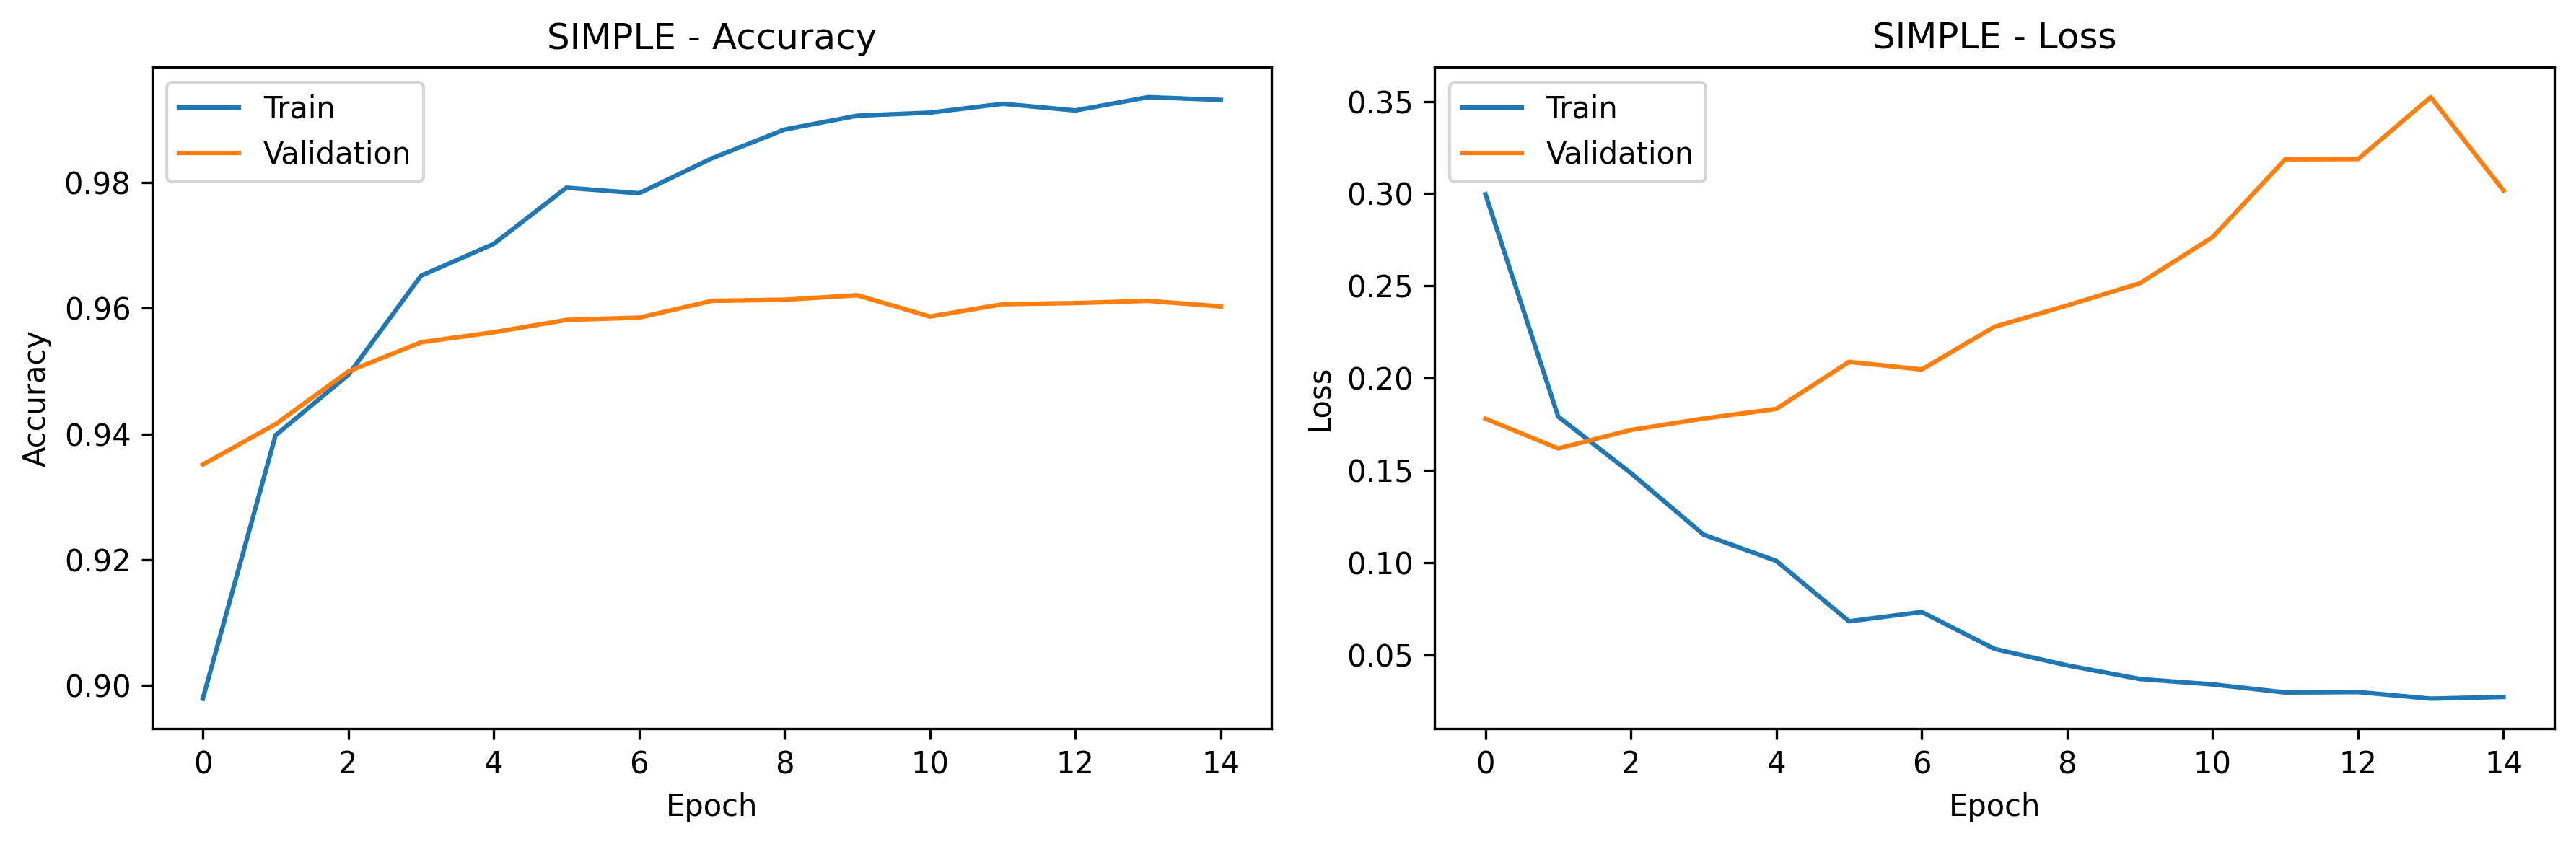

In [33]:
model_types = ['simple', 'lstm', 'gru']
plot_training_history(results[model_types[0]]["history"], model_types[0].upper()).show()

### Confusion Matrix (Simple)

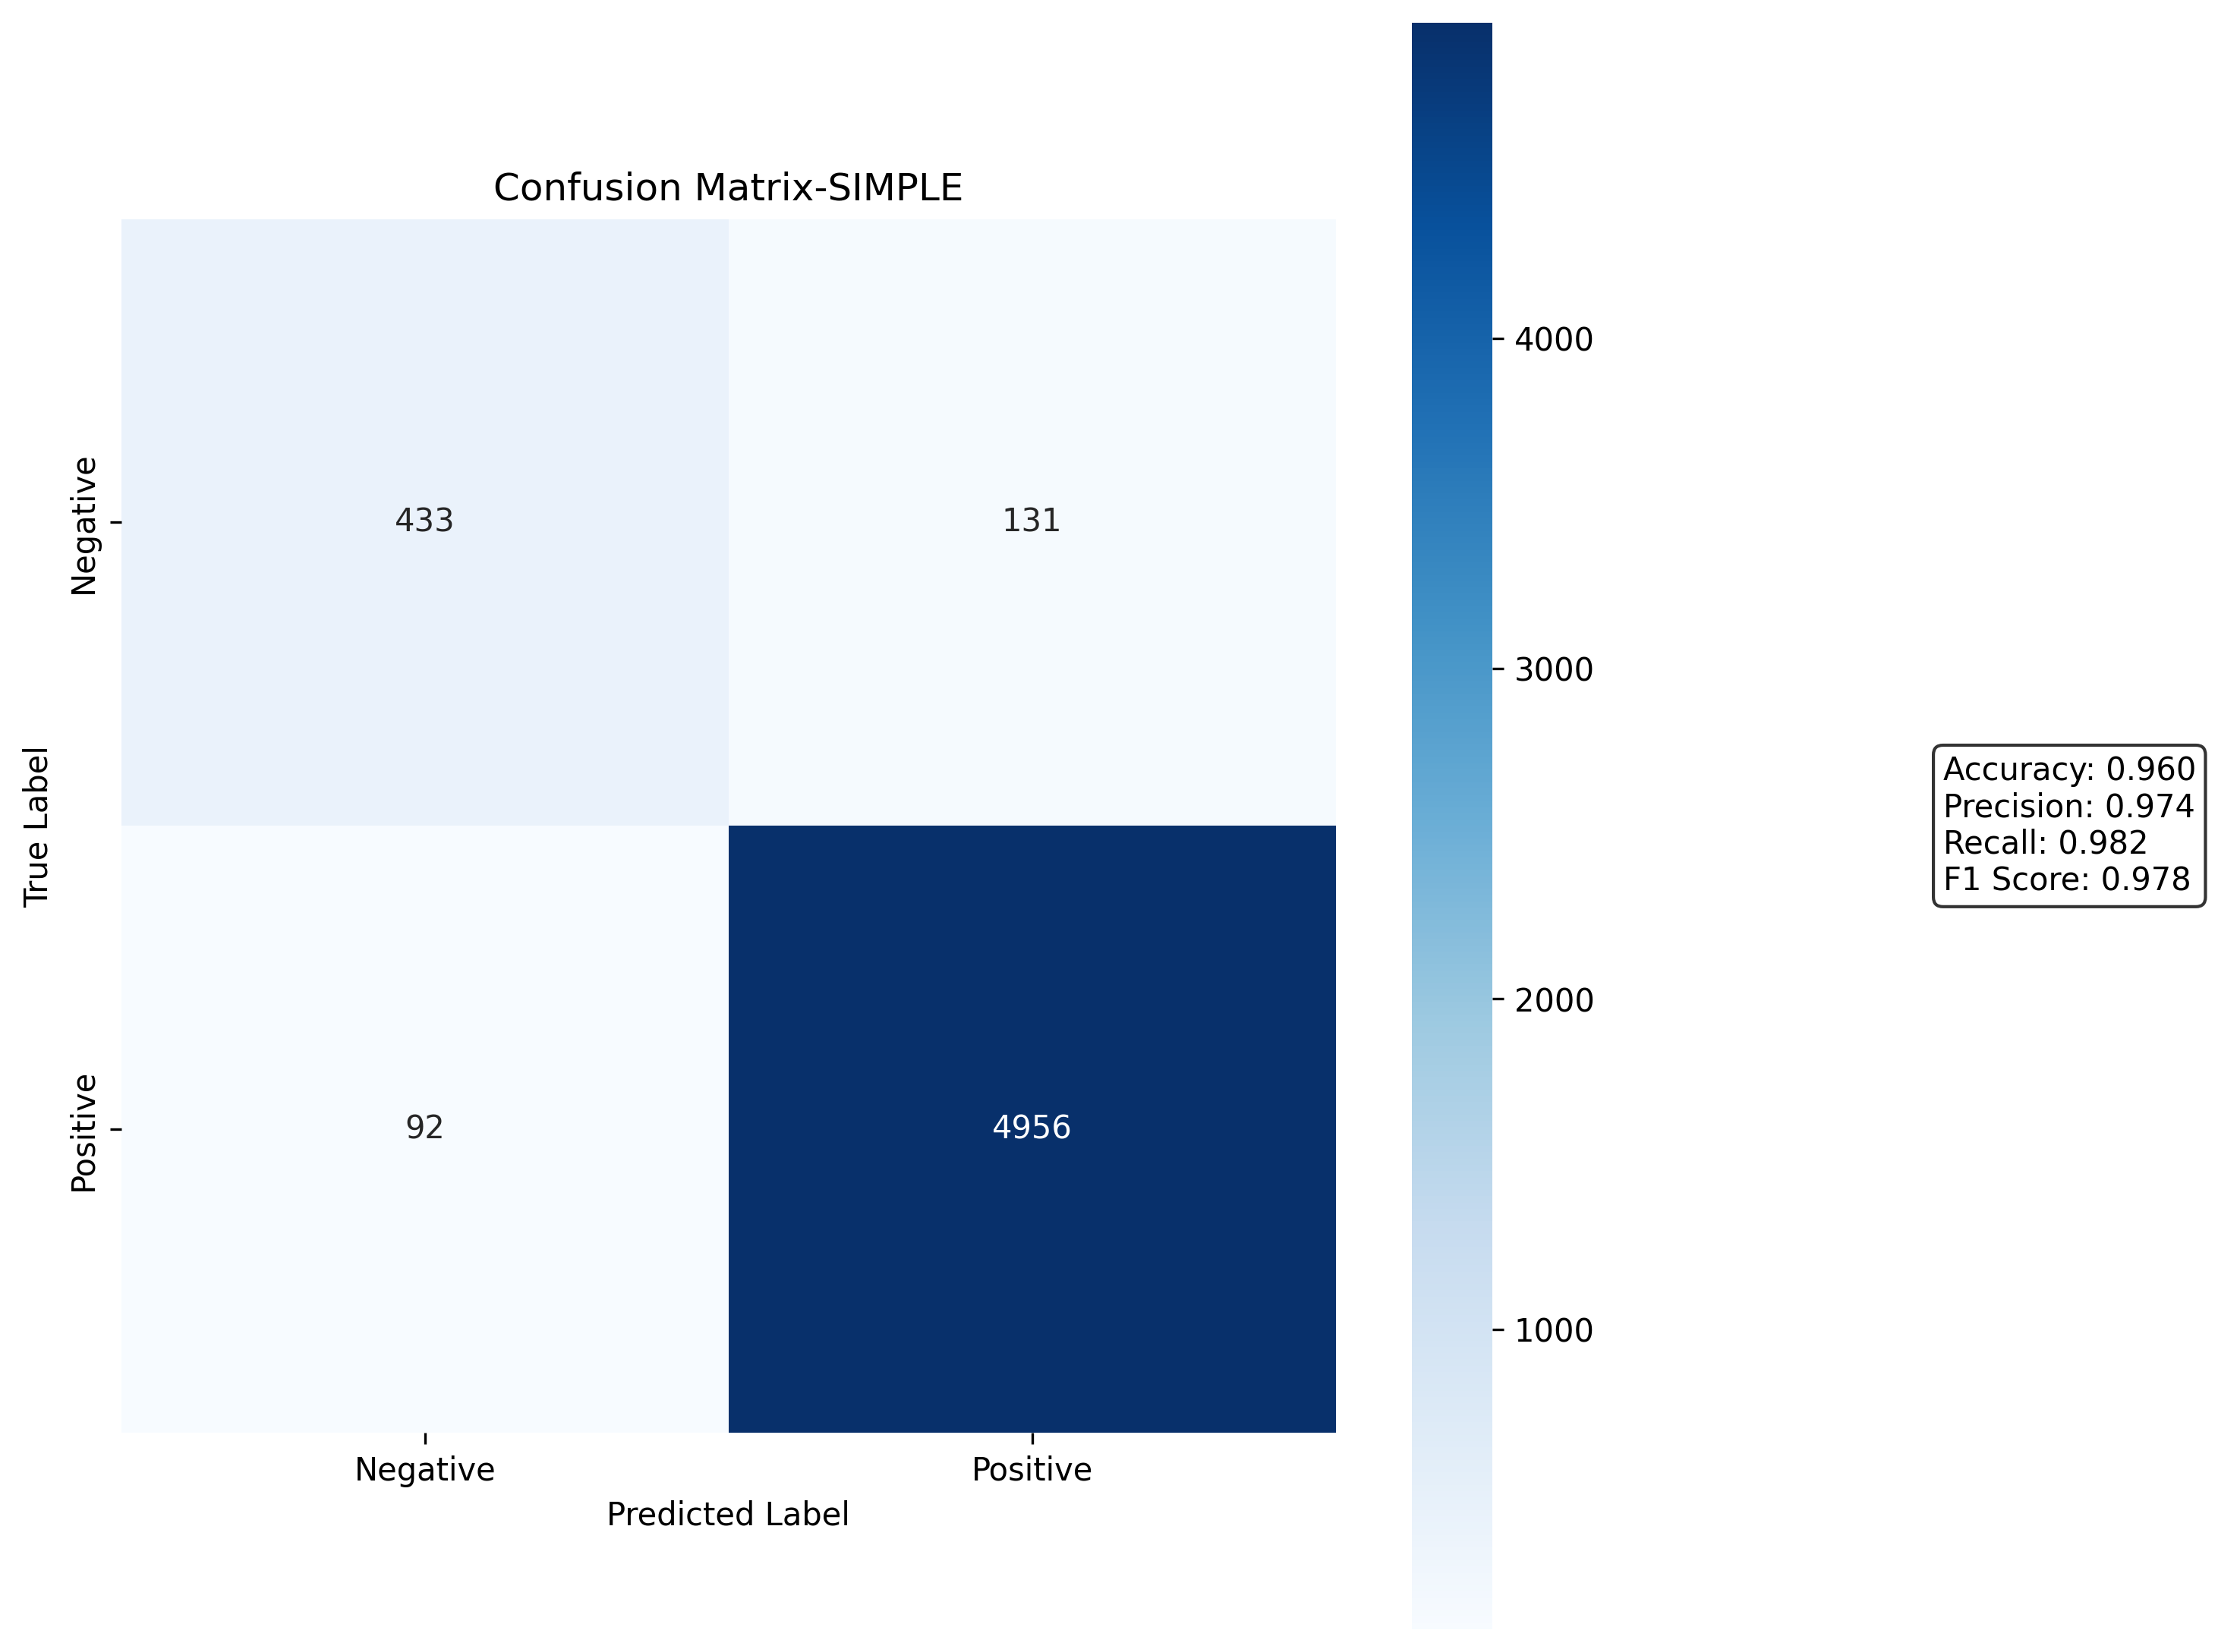

In [34]:
display_confusion_matrix(results[model_types[0]]["confusion_matrix"],model_types[0].upper()).show()

### Accuracy & Loss (LSTM)

I am in plot_training_history


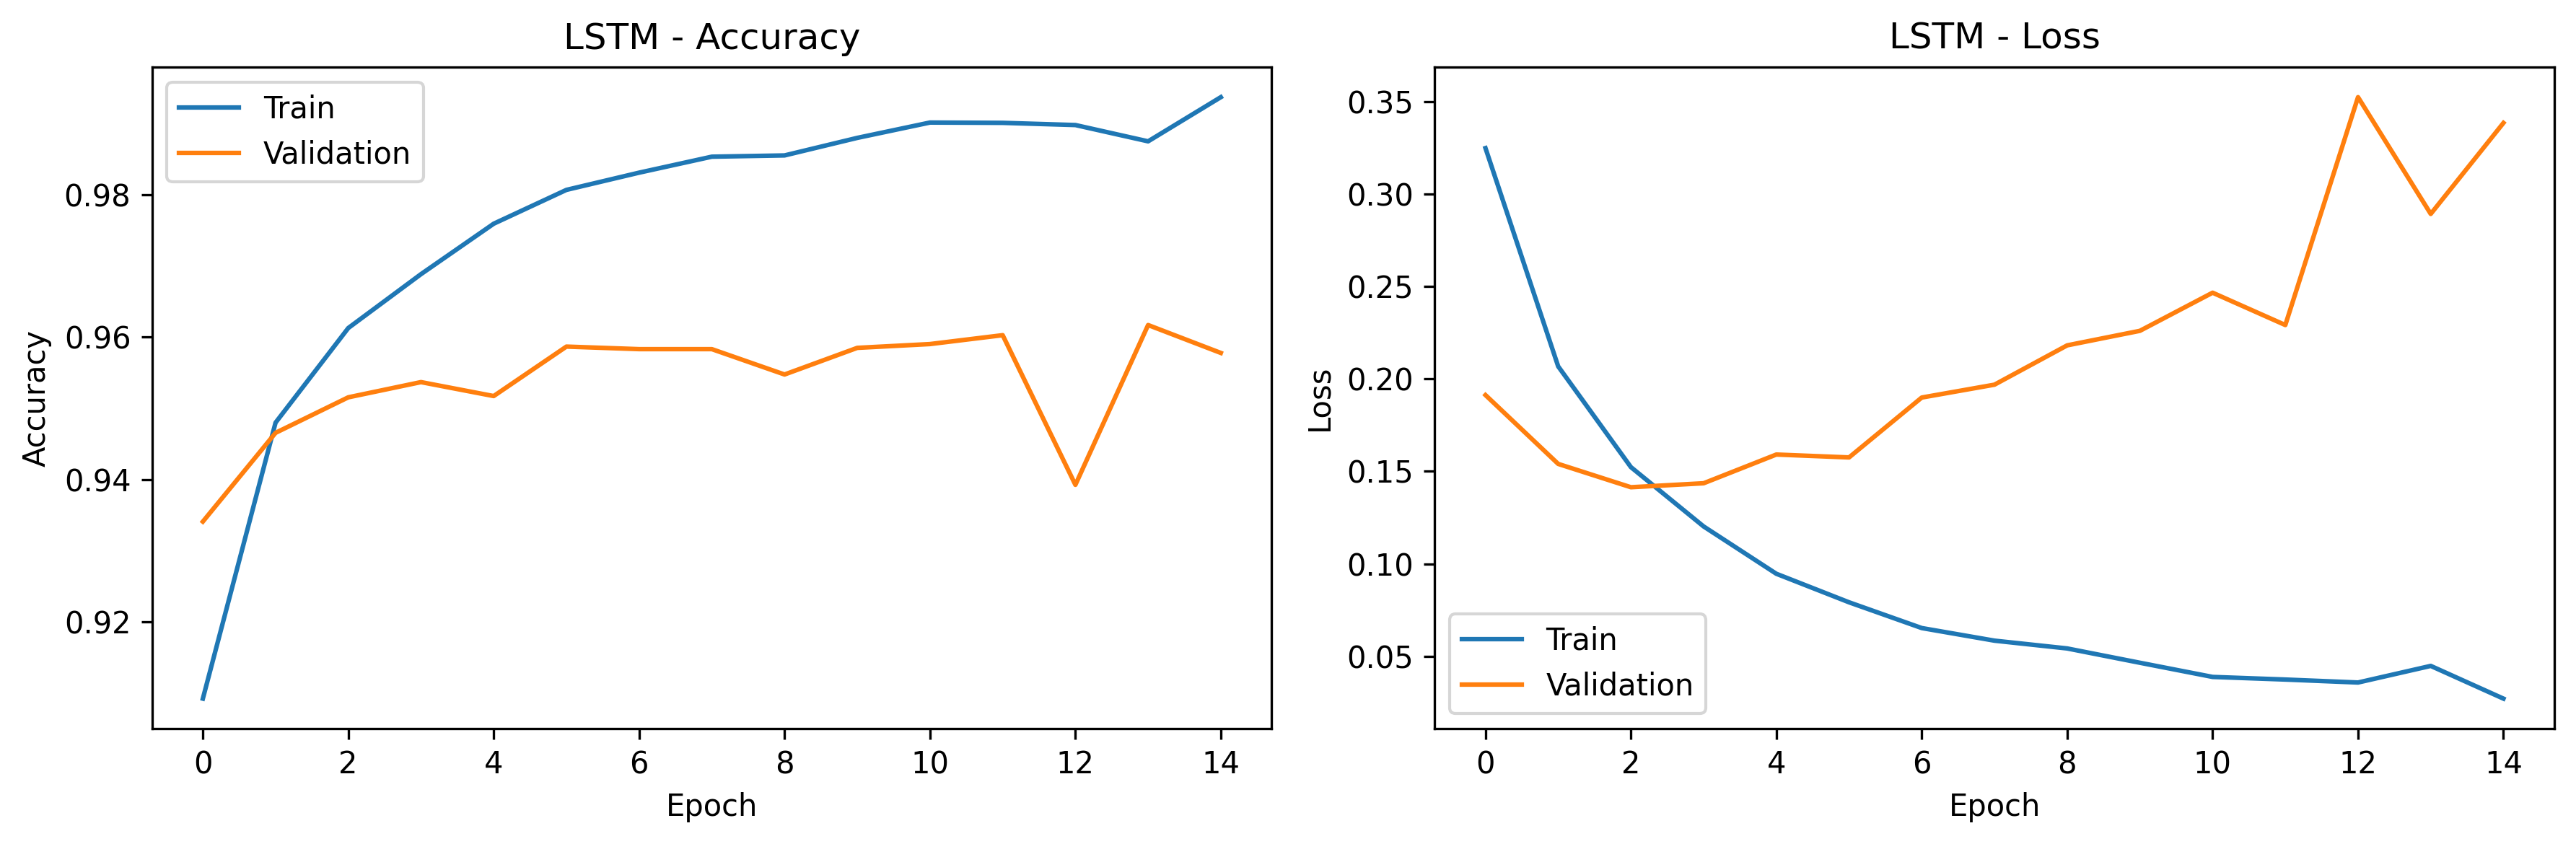

In [18]:
model_types = ['simple', 'lstm', 'gru']
plot_training_history(results[model_types[1]]["history"], model_types[1].upper()).show()

### Confusion Matrix(LSTM)

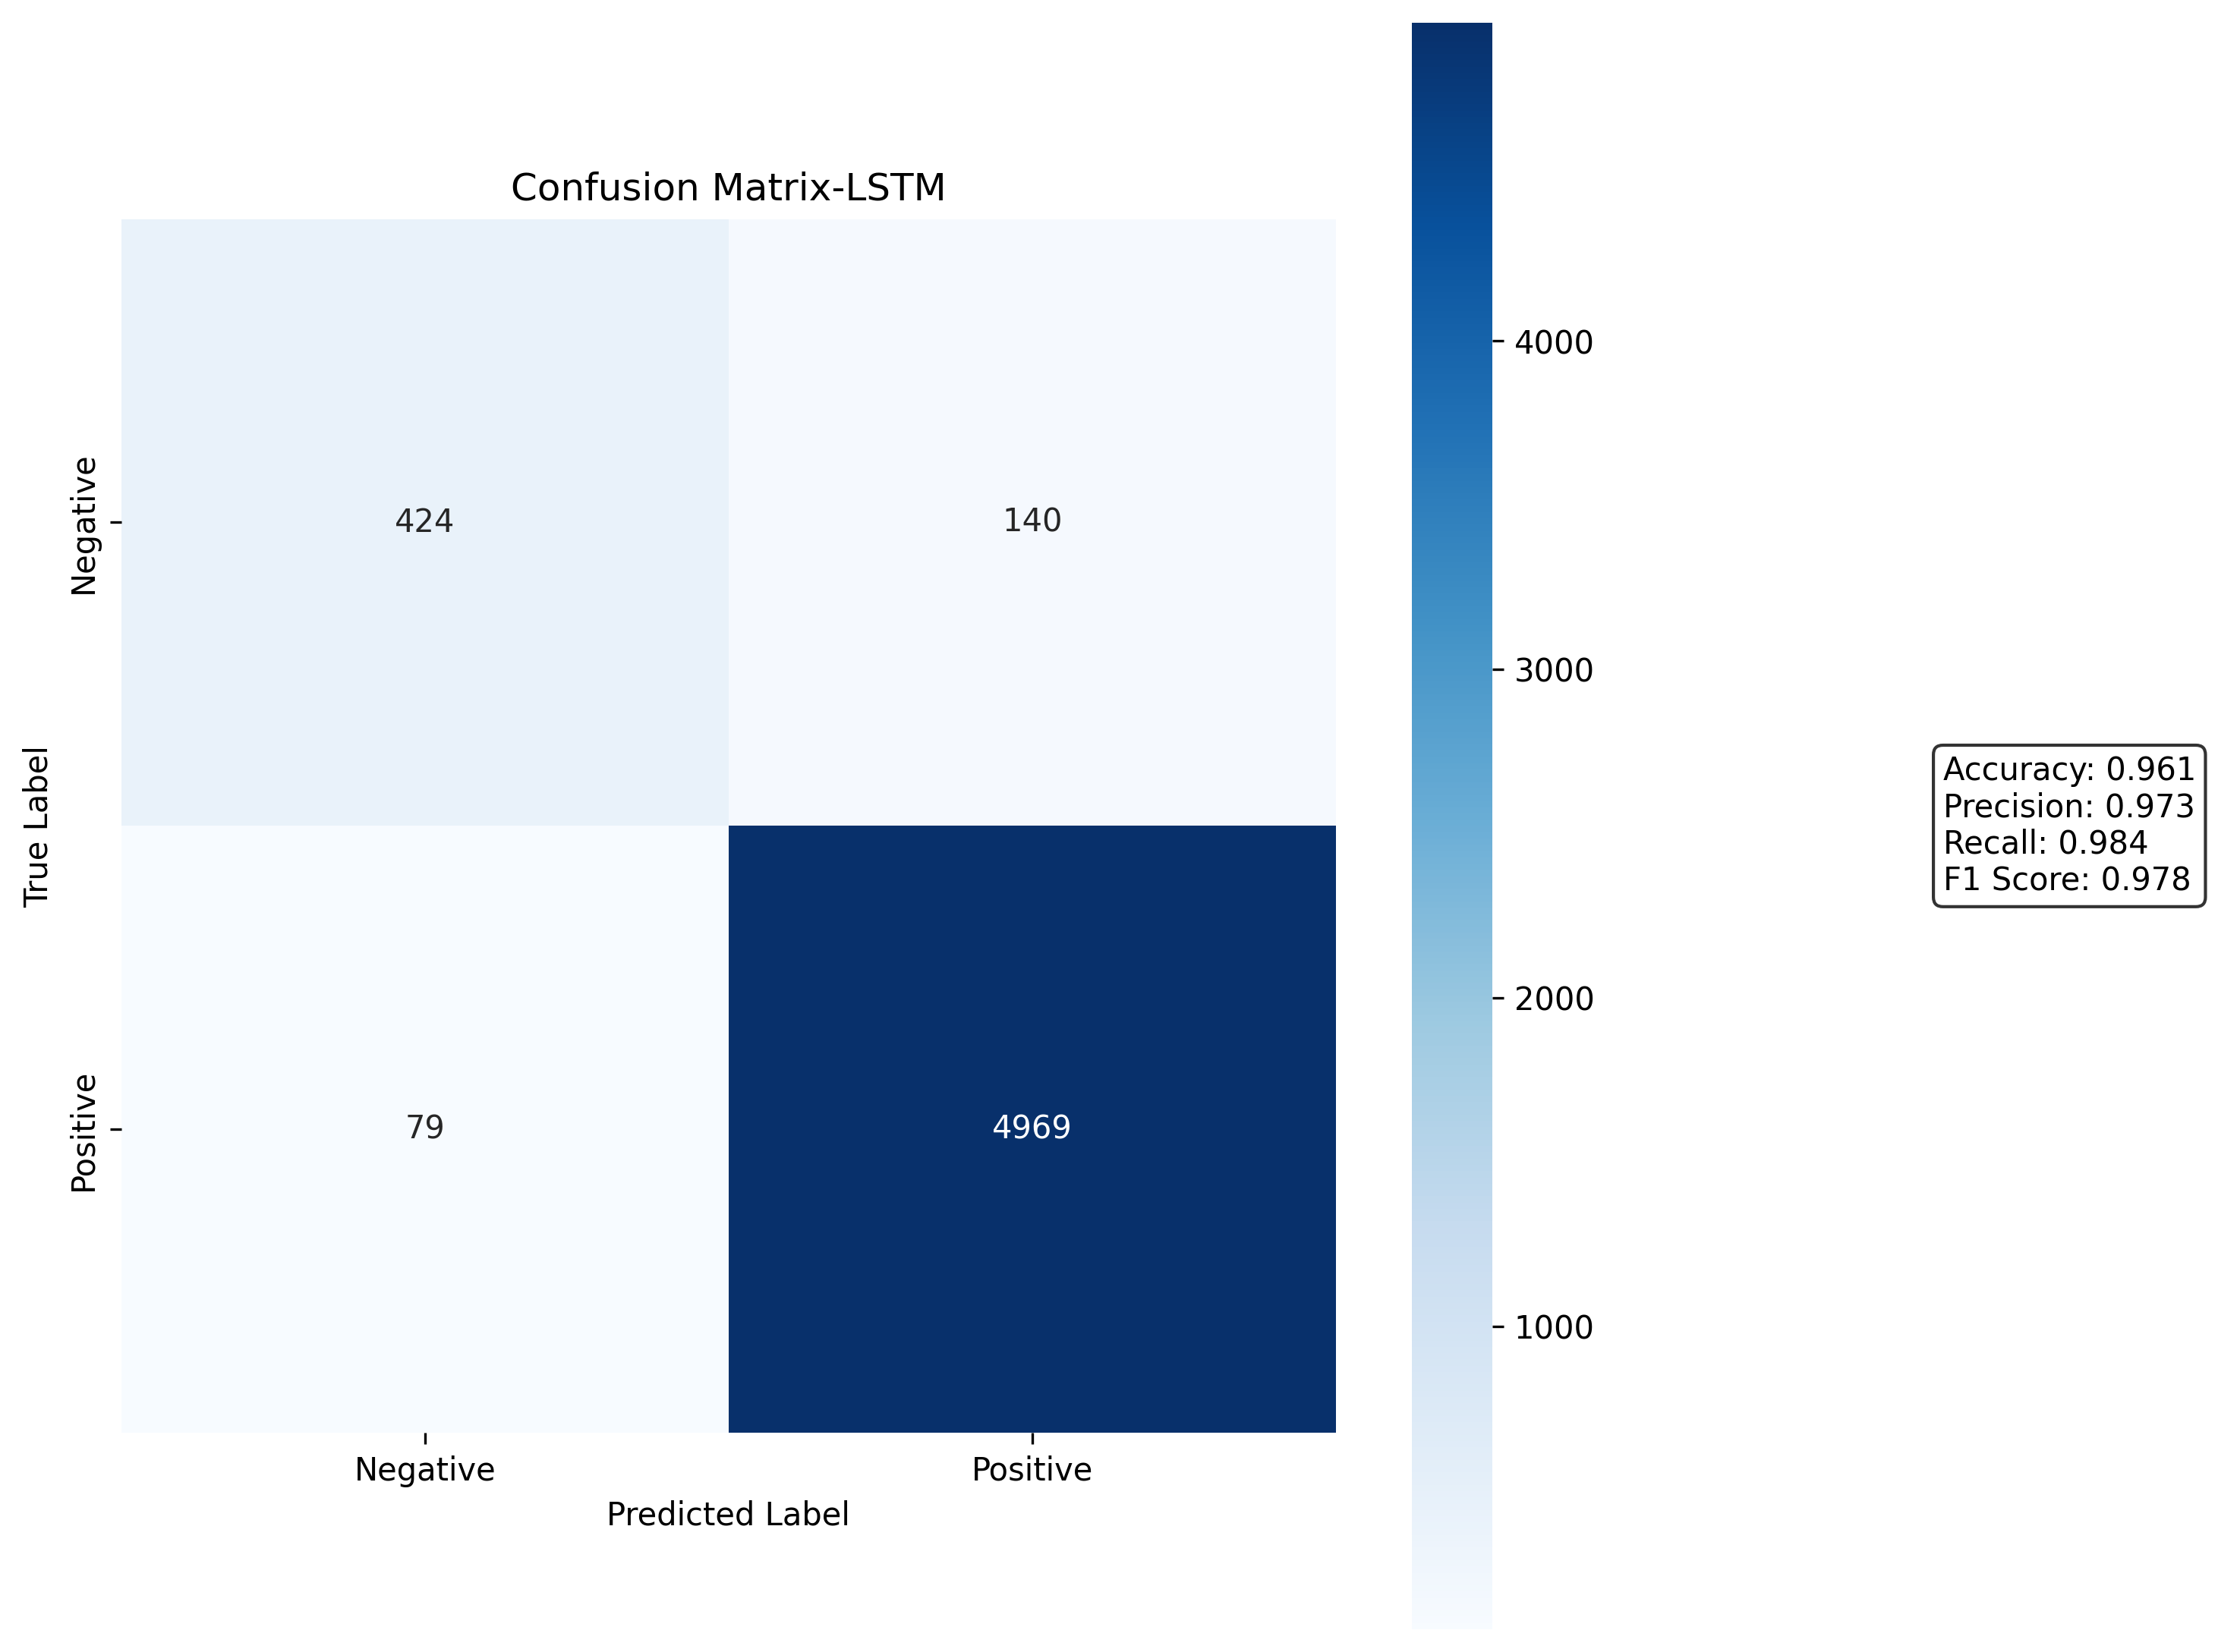

In [35]:
display_confusion_matrix(results[model_types[1]]["confusion_matrix"],model_types[1].upper()).show()

### Accuracy & Loss (GRU)

I am in plot_training_history


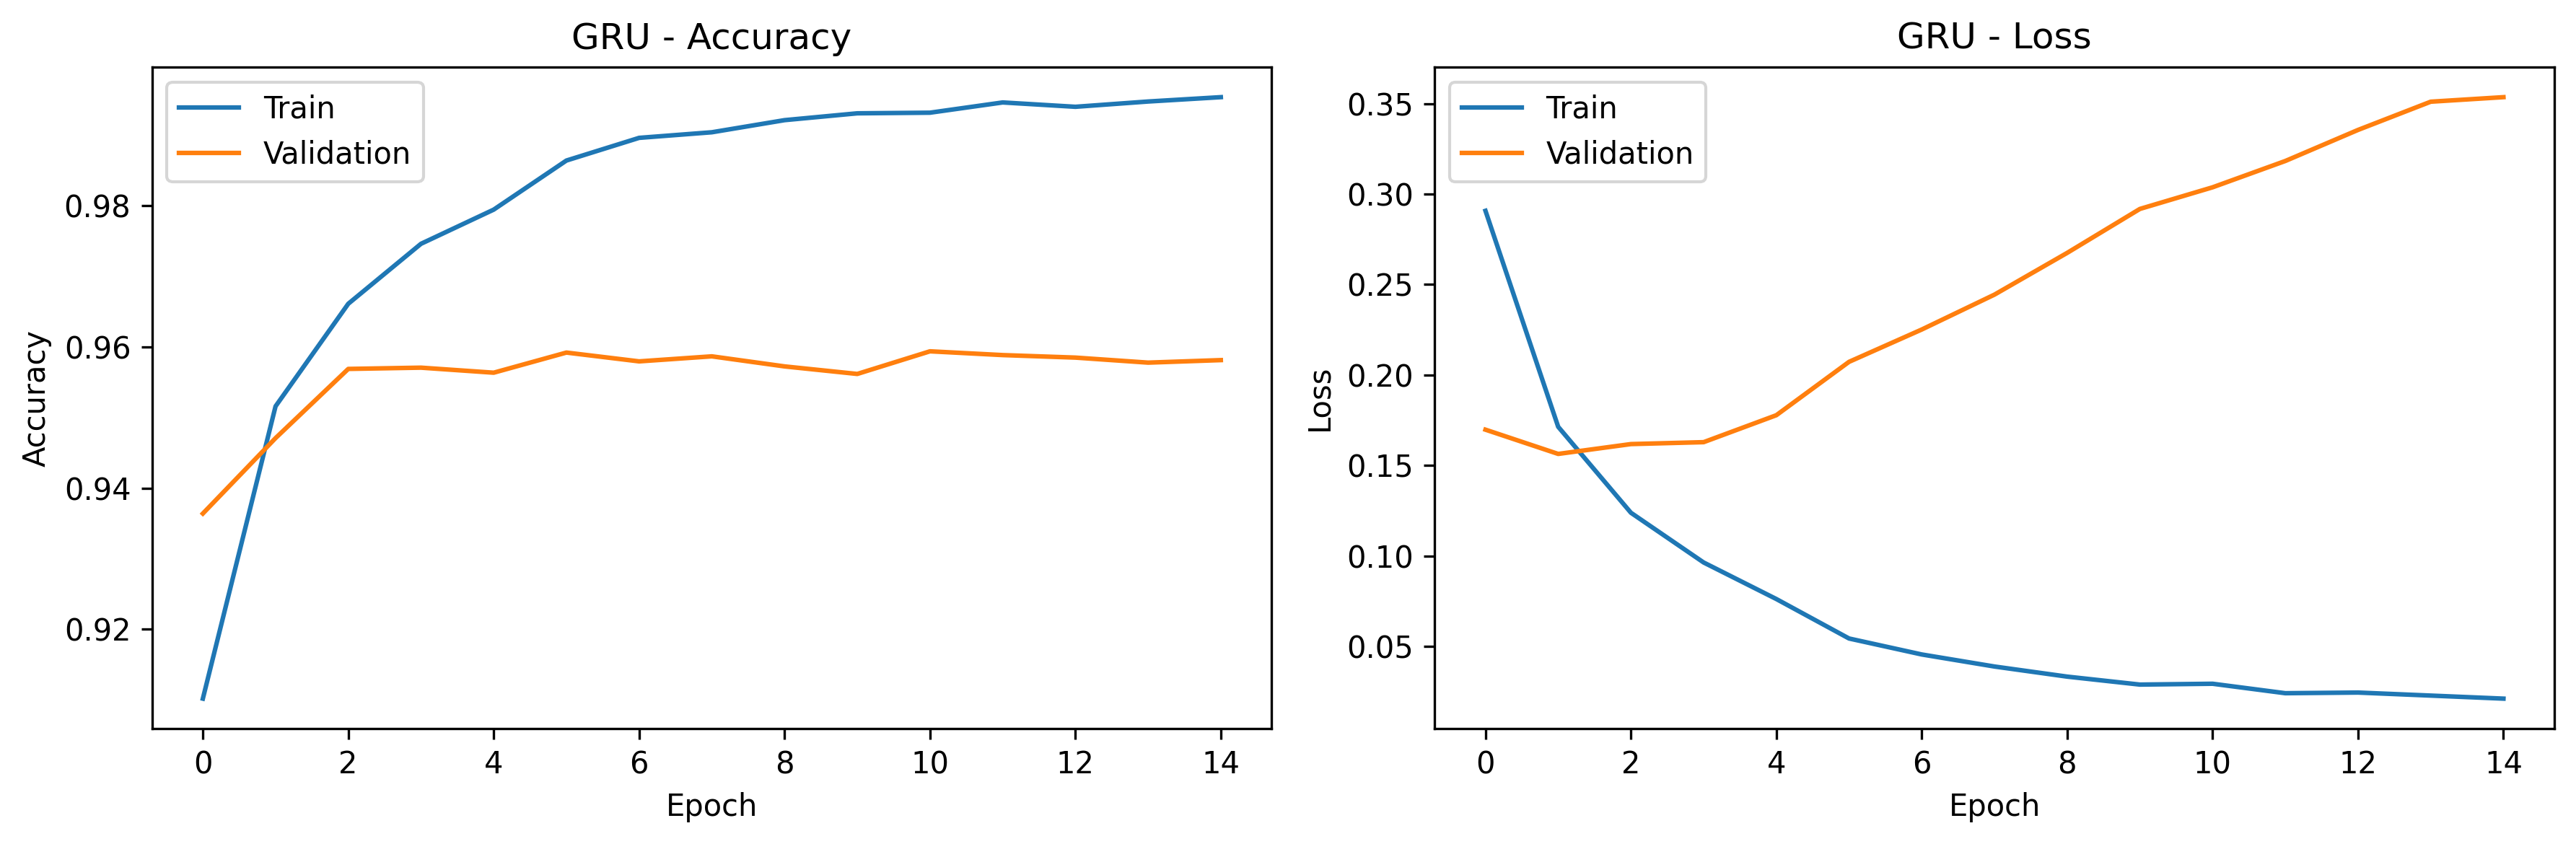

In [36]:
model_types = ['simple', 'lstm', 'gru']
plot_training_history(results[model_types[2]]["history"], model_types[2].upper()).show()

### Confusion Matrix (LSTM)

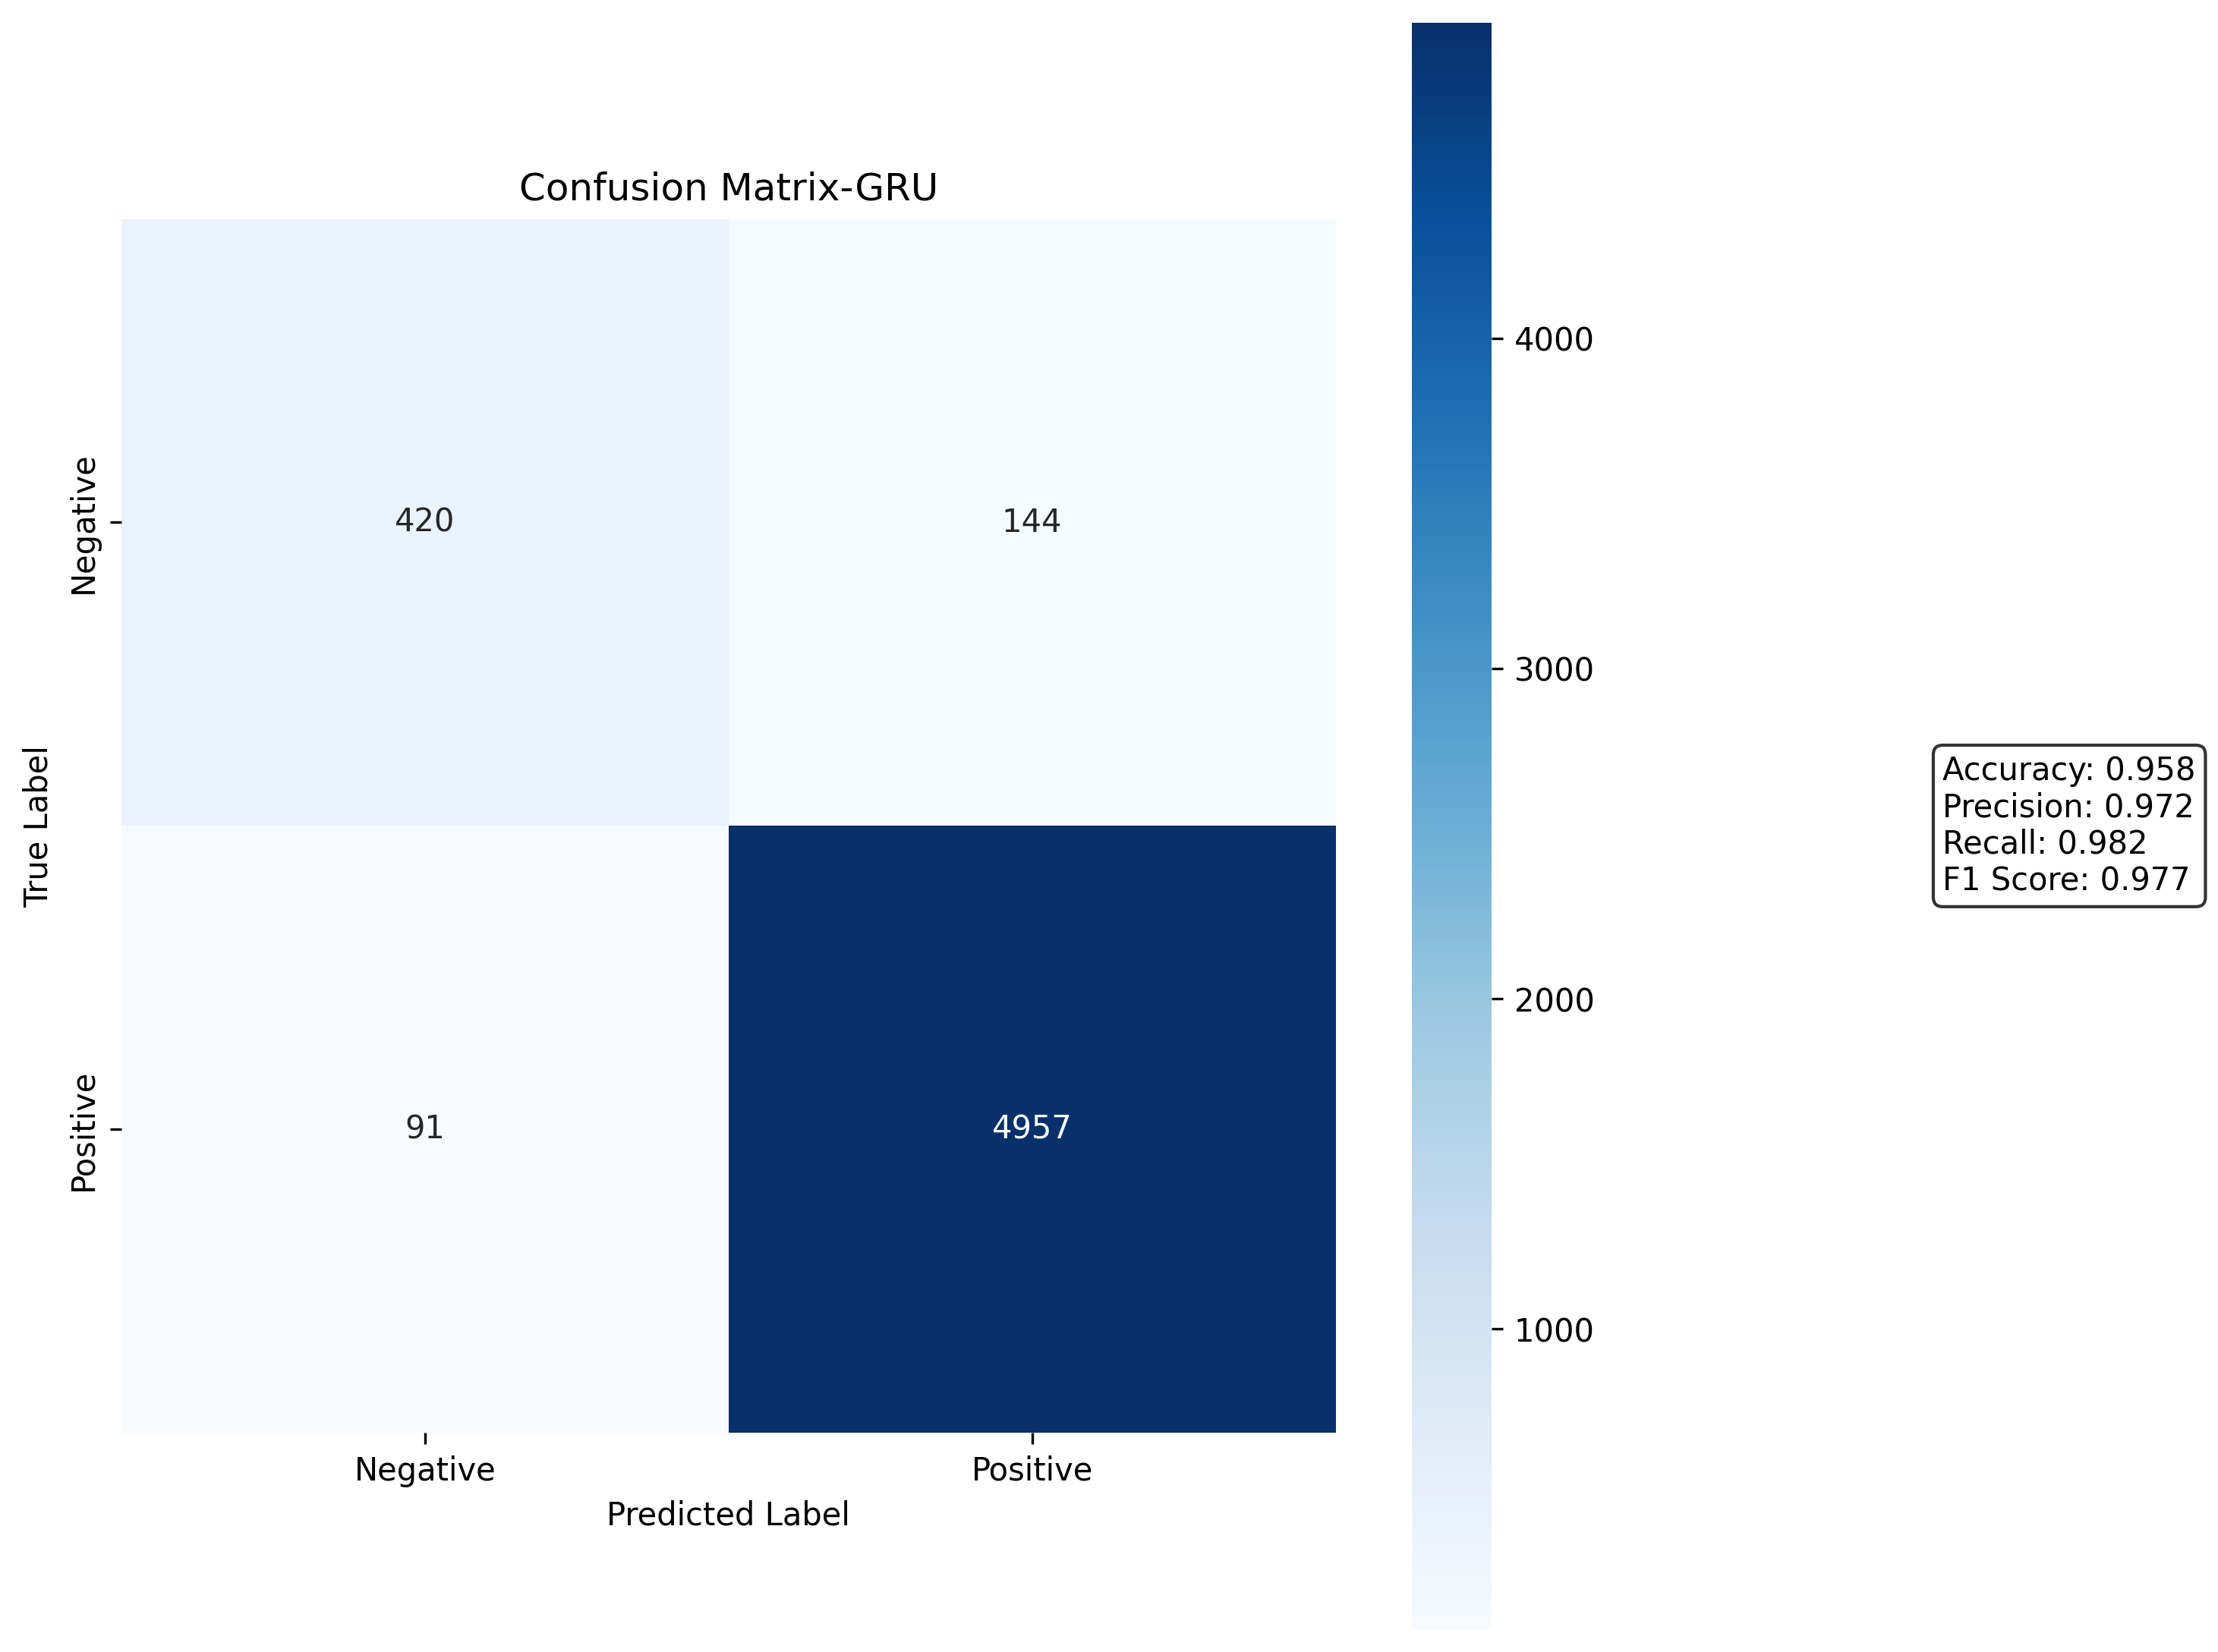

In [37]:
display_confusion_matrix(results[model_types[2]]["confusion_matrix"],model_types[2].upper()).show()

## Appendix

In [38]:
!nvidia-smi

Sun Mar 23 11:46:12 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.86.16              Driver Version: 572.16         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070 ...    On  |   00000000:01:00.0 Off |                  N/A |
|  0%   40C    P8              1W /  220W |   11509MiB /  12282MiB |      5%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [39]:
!nvidia-smi  -L

GPU 0: NVIDIA GeForce RTX 4070 SUPER (UUID: GPU-40292fc1-c848-a256-79c7-1ec1a07d8fa8)
